# Understanding Cost of Living Pressure in New Zealand

**Name:** Tasfia Mohtasim Toma 
**Student ID:** 25021047

## Introduction

The increasing expense of living has become a significant concern for households in New Zealand. Questioning whether households are capable of maintaining their standard of living has been prompted by the rise in essential expenses, including housing, food, and general consumer products.

The objective of this project is to investigate the impact of cost-of-living pressure through the examination of numerous datasets from Stats New Zealand, such as the Consumer Price Index (CPI), Household Living Cost Index (LCI), Rental Price Index, and Food Price Index. These datasets offer a comprehensive understanding of household-specific cost variations, overall inflation, and key expense categories.

The purpose of this analysis is to compare the trends in these datasets in order to comprehend the ways in which various components contribute to the cost-of-living pressure over time. The study aims to determine whether specific costs, such as housing or food, are increasing at a higher rate than general inflation by analyzing these patterns.

In conclusion, this analysis offers a data-driven comprehension of the manner in which cost-of-living pressures fluctuate in New Zealand and emphasizes the critical factors that may have a varying impact on households.

## List of Datasets Used and their Sources

The following datasets were used in this project:

1. Consumer Price Index (CPI)  
   Source: Stats New Zealand Data Explorer  
   Description: Measures changes in the overall price level of goods and services over time.

2. Household Living Cost Index (LCI)  
   Source: Stats New Zealand Data Explorer  
   Description: Shows cost of living changes experienced by different household types.

3. Rental Price Index  
   Source: Stats New Zealand Data Explorer  
   Description: Tracks changes in rental housing costs over time.

4. Food Price Index  
   Source: Stats New Zealand Data Explorer  
   Description: Measures changes in food prices, representing everyday living expenses.

The time periods covered by the datasets are marginally different. The analysis was limited to the common overlapping time frame (up to 2023) across all datasets for consistency.

## Research Questions

The subsequent research inquiries served as the foundation for this investigation:

1. What are the main economic indicators that have influenced the cost of living in New Zealand over time?
2. Is there a correlation between variations in household living costs (LCI) and overall inflation (CPI)?
3. What are the implications of this for the affordability of housing, and have rental prices increased at a higher rate than general inflation?
4. How does the Consumer Price Index (CPI) compare with food price trends?
5. What is the most significant contributor to the living cost: rent, food, or overall living expenses?

## Executive Summary

The cost-of-living trends in New Zealand are examined in this project using four critical datasets: the Consumer Price Index (CPI), Living Cost Index (LCI), the Rental Price Index, and the Food Price Index. The primary contributors to household financial pressure are identified by comparing overall inflation with specific cost components in the analysis.

The results suggest that, despite the consistent rise in inflation as a whole, specific components, such as housing and food costs, have experienced a more significant increase in the past. This implies that the cost-of-living pressure is not uniformly distributed across all expense categories.

The outcomes emphasize the significance of examining a variety of indicators when evaluating economic conditions, as general inflation may not adequately represent the financial obstacles that households encounter.

## Data Wrangling

The datasets were cleaned and organized to provide consistent and comparable results across all variables. This procedure entailed the selection of pertinent columns, the renaming of variables to improve legibility, the management of missing values and the standardization of time formats.

The datasets were aligned by limiting the analysis to the common overlapping time range, as they spanned slightly different time periods. This guarantees the precise comparison of cost-of-living indicators. Before being combined into a singular dataset for additional analysis, each dataset was processed independently.

### Load Data

In [1]:
import pandas as pd
import os

# Set base path (same folder as notebook recommended)
base_path = os.getcwd()

# Load datasets
cpi = pd.read_csv(os.path.join(base_path, "consumers-price-index-december-2025-quarter-index-numbers.csv"))
food = pd.read_csv(os.path.join(base_path, "food-price-index-september-2023-index-numbers.csv"))
lci = pd.read_csv(os.path.join(base_path, "household-living-costs-price-indexes-december-2025-quarter-time-series-indexes.csv"))
rent = pd.read_csv(os.path.join(base_path, "rental-price-indexes-september-2023.csv"))

# Preview
cpi.head()

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2
0,CPIQ.SE901,1914.06,13.167858,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
1,CPIQ.SE901,1914.09,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
2,CPIQ.SE901,1914.12,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
3,CPIQ.SE901,1915.03,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN
4,CPIQ.SE901,1915.06,0.000000,FINAL,Index,CPI,CPI Level 1 Groups for New Zealand,Food,NaN


### Initial data review

In [2]:
cpi.columns
lci.columns
rent.columns
food.columns

Index(['Series_reference', 'Period', 'Data_value', 'STATUS', 'UNITS',
       'Subject', 'Group', 'Series_title_1'],
      dtype='object')

### Cleaning CPI Dataset

In [3]:
cpi = cpi[['Period', 'Data_value']]
cpi.columns = ['Time', 'CPI']
cpi = cpi.dropna()
cpi = cpi.sort_values(by='Time')

cpi.head()

,Time,CPI
0,1914.06,13.167858
21928,1914.06,12.869674
1,1914.09,0.000000
2,1914.12,0.000000
3,1915.03,0.000000


### Cleaning LCI Dataset

In [4]:
lci = lci[['quarter', 'index']].copy()
lci.columns = ['Time', 'LCI']
lci = lci.dropna()
lci = lci.sort_values(by='Time')

lci.head()

,Time,LCI
0,2008Q2,870
34719,2008Q2,868
34790,2008Q2,860
34861,2008Q2,882
34932,2008Q2,864


### Cleaning Rental Dataset

In [5]:
rent.columns.tolist()
rent.head()

,SER_REF,TIME_REF,DATA_VAL,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE1041F,2006.11,1000,FINAL,Index,CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
1,CPIM.SE1041F,2006.12,995,FINAL,Index,CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
2,CPIM.SE1041F,2007.01,1007,FINAL,Index,CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
3,CPIM.SE1041F,2007.02,1012,FINAL,Index,CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow
4,CPIM.SE1041F,2007.03,1020,FINAL,Index,CPI,CPI Monthly Rents (Broad Regions),Auckland,Actual rentals for housing,Flow


In [6]:
rent[['Series_title_1', 'Series_title_2', 'Series_title_3']].head()
rent['Series_title_1'].unique()[:20]

array(['Auckland', 'Wellington', 'Rest of North Island', 'Canterbury',
       'Rest of South Island', 'National'], dtype=object)

In [7]:
rent = rent[rent['Series_title_1'] == 'National'].copy()
rent = rent[['TIME_REF', 'DATA_VAL']].copy()
rent.columns = ['Time', 'Rent']
rent = rent.dropna()
rent = rent.sort_values(by='Time')

rent.head()

,Time,Rent
1015,2006.11,1000
1218,2006.12,1000
1016,2006.12,992
1017,2007.01,1025
1219,2007.01,1004


### Cleaning Food Dataset

In [8]:
food = food[['Period', 'Data_value']]
food.columns = ['Time', 'Food']
food = food.dropna()
food = food.sort_values(by='Time')

In [9]:
cpi['Year'] = cpi['Time'].astype(str).str[:4]
lci['Year'] = lci['Time'].astype(str).str[:4]
rent['Year'] = rent['Time'].astype(str).str[:4]
food['Year'] = food['Time'].astype(str).str[:4]

### Standardize Time

In [10]:
df_cpi_year = cpi.groupby('Year', as_index=False)['CPI'].mean()
df_lci_year = lci.groupby('Year', as_index=False)['LCI'].mean()
df_rent_year = rent.groupby('Year', as_index=False)['Rent'].mean()
df_food_year = food.groupby('Year', as_index=False)['Food'].mean()

### Merge Datasets

In [11]:
df = pd.merge(df_cpi_year, df_lci_year, on='Year', how='inner')
df = pd.merge(df, df_rent_year, on='Year', how='inner')
df = pd.merge(df, df_food_year, on='Year', how='inner')

df.head()

,Year,CPI,LCI,Rent,Food
0,2008,1003.830032,971.628025,1076.166667,876.101342
1,2009,1010.243468,973.927986,1091.583333,930.958053
2,2010,1003.685475,973.771077,1112.166667,937.929745
3,2011,1011.841753,992.060890,1143.291667,984.993063
4,2012,1000.465571,990.226581,1179.416667,976.888861


### Align timeframe

In [12]:
df = df[df['Year'] <= '2023']
df.head()

,Year,CPI,LCI,Rent,Food
0,2008,1003.830032,971.628025,1076.166667,876.101342
1,2009,1010.243468,973.927986,1091.583333,930.958053
2,2010,1003.685475,973.771077,1112.166667,937.929745
3,2011,1011.841753,992.060890,1143.291667,984.993063
4,2012,1000.465571,990.226581,1179.416667,976.888861


### Creating New Variables from the Datasets

In [13]:
df['CPI_growth'] = df['CPI'].pct_change()
df['Rent_growth'] = df['Rent'].pct_change()
df['Food_growth'] = df['Food'].pct_change()
df['LCI_growth'] = df['LCI'].pct_change()

### Difference between rent and CPI

In [14]:
df['Rent_vs_CPI'] = df['Rent_growth'] - df['CPI_growth']

### Difference between Food vs CPI

In [15]:
df['Food_vs_CPI'] = df['Food_growth'] - df['CPI_growth']

In [16]:
df.head()

,Year,CPI,LCI,Rent,Food,CPI_growth,Rent_growth,Food_growth,LCI_growth,Rent_vs_CPI,Food_vs_CPI
0,2008,1003.830032,971.628025,1076.166667,876.101342,NaN,NaN,NaN,NaN,NaN,NaN
1,2009,1010.243468,973.927986,1091.583333,930.958053,0.006389,0.014326,0.062615,0.002367,0.007937,0.056226
2,2010,1003.685475,973.771077,1112.166667,937.929745,-0.006491,0.018856,0.007489,-0.000161,0.025348,0.013980
3,2011,1011.841753,992.060890,1143.291667,984.993063,0.008126,0.027986,0.050178,0.018782,0.019860,0.042052
4,2012,1000.465571,990.226581,1179.416667,976.888861,-0.011243,0.031597,-0.008228,-0.001849,0.042840,0.003015


Using the time variable, the datasets were integrated to produce a unified dataset following the cleaning process. This enables the direct comparison of various living expense indicators.

In order to facilitate a more comprehensive investigation into cost-of-living trends, additional variables were developed. To investigate the evolution of various cost components over time, growth rates were computed. In addition, comparative variables were developed to determine whether specific expenses, including housing and food, increase at a faster pace than the general inflation rate.

In [17]:
df = df.dropna()
df.head()

,Year,CPI,LCI,Rent,Food,CPI_growth,Rent_growth,Food_growth,LCI_growth,Rent_vs_CPI,Food_vs_CPI
1,2009,1010.243468,973.927986,1091.583333,930.958053,0.006389,0.014326,0.062615,0.002367,0.007937,0.056226
2,2010,1003.685475,973.771077,1112.166667,937.929745,-0.006491,0.018856,0.007489,-0.000161,0.025348,0.013980
3,2011,1011.841753,992.060890,1143.291667,984.993063,0.008126,0.027986,0.050178,0.018782,0.019860,0.042052
4,2012,1000.465571,990.226581,1179.416667,976.888861,-0.011243,0.031597,-0.008228,-0.001849,0.042840,0.003015
5,2013,993.913118,993.738583,1212.958333,980.402108,-0.006549,0.028439,0.003596,0.003547,0.034989,0.010146


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 1 to 15
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         15 non-null     object 
 1   CPI          15 non-null     float64
 2   LCI          15 non-null     float64
 3   Rent         15 non-null     float64
 4   Food         15 non-null     float64
 5   CPI_growth   15 non-null     float64
 6   Rent_growth  15 non-null     float64
 7   Food_growth  15 non-null     float64
 8   LCI_growth   15 non-null     float64
 9   Rent_vs_CPI  15 non-null     float64
 10  Food_vs_CPI  15 non-null     float64
dtypes: float64(10), object(1)
memory usage: 1.4+ KB


Both the original index values and the calculated growth rates for each cost component are included in the final dataset. The initial observation was eliminated as a result of the growth rate calculation yielding absent values. This filtered dataset is employed for additional analysis.

In [19]:
df['Year'] = df['Year'].astype(int)

In order to provide accurate ordering and enhance consistency with visualization and analysis, the Year variable was converted to a numeric format.

## Exploratory Data Analysis

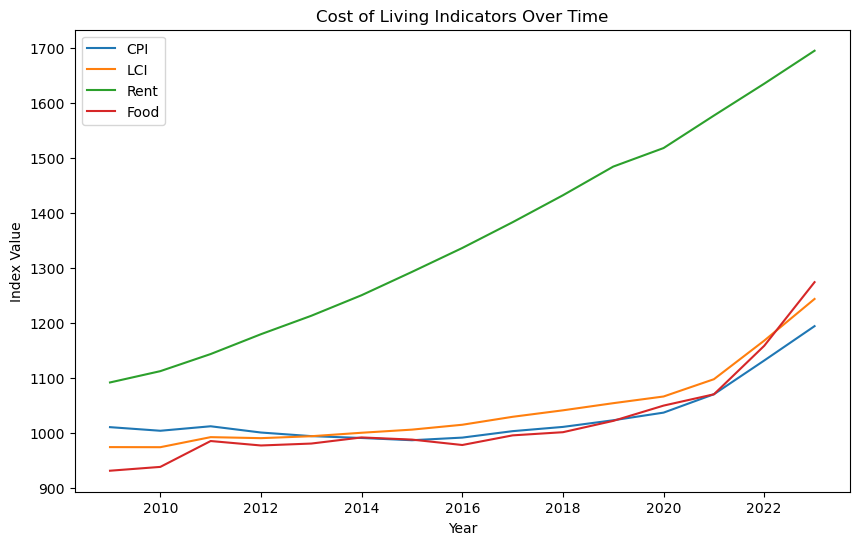

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df['Year'], df['CPI'], label='CPI')
plt.plot(df['Year'], df['LCI'], label='LCI')
plt.plot(df['Year'], df['Rent'], label='Rent')
plt.plot(df['Year'], df['Food'], label='Food')

plt.title("Cost of Living Indicators Over Time")
plt.xlabel("Year")
plt.ylabel("Index Value")
plt.legend()

plt.show()

The graph illustrates that the cost-of-living indicators in New Zealand have all risen over time. The most rapid and consistent increase in rental prices suggests that housing is the primary factor contributing to the cost-of-living pressure.

The gradual increase in CPI and LCI indicates that the sharp rise in housing costs is not completely captured by general inflation. The pressure on households is further exacerbated by the rise in food prices, particularly in recent years.

On the whole, the findings indicate that the primary source of cost-of-living pressure is essential expenditures, such as housing and food, rather than general inflation.

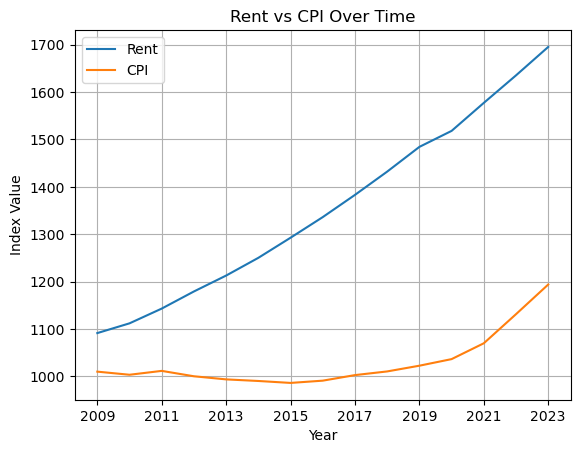

In [21]:
import matplotlib.pyplot as plt

# Create Year
df['Year'] = df.get('Time', df['Year']).astype(str).str[:4]

# Yearly data
df_year = df.groupby('Year')[['CPI','LCI','Rent','Food']].mean().reset_index()

# Plot
df_year.plot(x='Year', y=['Rent','CPI'], title='Rent vs CPI Over Time')
plt.xlabel('Year')
plt.ylabel('Index Value')
plt.grid(True)
plt.show()

The graph indicates that rental prices have increased at a significantly higher rate than the Consumer Price Index (CPI) over time. Although the Consumer Price Index (CPI) experiences a progressive increase, rent exhibits a consistent and rapid upward progression.

This suggests that rent is a significant contributor to the cost-of-living pressure in New Zealand, as housing costs are increasing at a higher rate than general inflation.

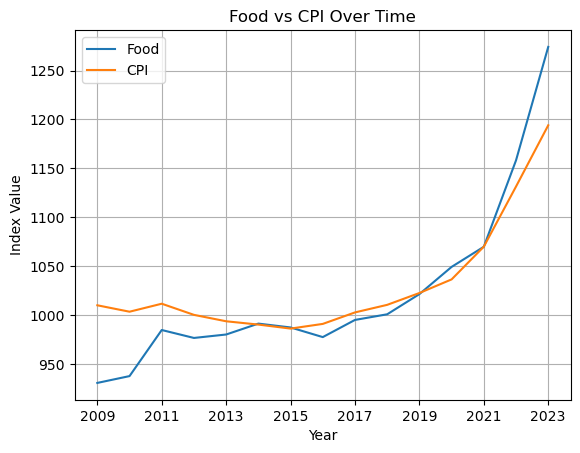

In [22]:
df_year.plot(x='Year', y=['Food','CPI'], title='Food vs CPI Over Time')
plt.xlabel('Year')
plt.ylabel('Index Value')
plt.grid(True)
plt.show()

Initially, the graph demonstrates that food prices and the Consumer Price Index (CPI) exhibit comparable trends; however, in recent years, food prices have increased at a more rapid pace.

This implies that food prices are increasing at a higher rate than general inflation, particularly after 2020, which is putting additional financial strain on households.

## Correlation

In [23]:
df[['CPI','LCI','Rent','Food']].corr()

,CPI,LCI,Rent,Food
CPI,1.000000,0.958304,0.773035,0.958713
LCI,0.958304,1.000000,0.910976,0.986416
Rent,0.773035,0.910976,1.000000,0.859190
Food,0.958713,0.986416,0.859190,1.000000


To acquire a more comprehensive understanding of the relationships between the main indicators, a correlation analysis was implemented. The results indicate that all variables are positively correlated, suggesting that increases in one measure are typically associated with increases in others.

The strongest relationships are observed between CPI, LCI, and rental prices, indicating that housing costs are closely associated with broader inflationary factors. Nevertheless, the more pronounced increase in rental prices than in the Consumer Price Index (CPI) suggests that housing is the primary factor contributing to the cost of living pressure.

## Analysis and Findings

The examination of cost-of-living indicators in New Zealand reveals a number of noteworthy trends. In general, the cost of living has increased steadily, as illustrated by the upward movement of all indicators over time.

Among all components, rental prices demonstrate the most substantial and consistent development. This suggests that the cost-of-living pressure is primarily driven by housing expenditures. The increasing financial burden on households, particularly in relation to essential accommodation expenditures, is underscored by the rapid and sustained increase in rent.

Furthermore, there has been a discernible upward trend in the price of food, particularly in recent years. This implies that the cost of basic everyday needs is rising. As a result, even basic consumption expenses are dramatically increasing household financial stress, validating the notion that inflation particularly impacts necessary items rather than discretionary spending.

Rental prices have consistently increased at a higher rate than general inflation, as evidenced by a direct comparison between the Consumer Price Index (CPI) and rental prices. This underscores a structural imbalance, in which housing costs are increasing at a rate that exceeds the general price level. As a result, this implies that the true financial burden that households face may be underestimated by the Consumer Price Index (CPI).

Although the Consumer Price Index (CPI) and the Living Cost Index (LCI) reflect broadly similar patterns, there are significant distinctions between them. Household-specific cost variations are captured by the LCI, which subsequently offers a more accurate representation of the actual cost pressures that individuals encounter. This suggests that general inflation measures may not accurately represent the lived economic experiences of individuals.

In general, the results indicate that the burden of cost-of-living pressure is not equitably distributed among all categories. As time has progressed, it has become increasingly evident that essential components, such as housing and sustenance, are the primary factors contributing to financial stress.

## Conclusion

Using data from the Consumer Price Index (CPI), the Labour Cost Index (LCI), the rental price index, and the food price index, this study investigated the trends in the cost of living in New Zealand. These findings indicate that the cost of living has increased over time, with housing and food costs being the primary factors.

The analysis emphasizes that housing is a significant contributor to financial pressure, as rental prices have increased at a faster pace than overall inflation. Food prices also contribute to the rise in daily expenses for households.

These results indicate that the cost-of-living challenges that households encounter are not entirely accounted for by general inflation. In order to comprehend the genuine economic implications, it is critical to conduct a more comprehensive examination of various cost components.

## Reflective Summary

This project presented significant knowledge in modifying on real-world datasets. One of the primary obstacles was the management of datasets with varying time formats and structures. This necessitated meticulous data cleansing and transformation to guarantee uniformity.

Another obstacle was the selection of appropriate variables and the development of meaningful derived variables for analysis. During this process, I acquired a more comprehensive comprehension of exploratory analysis and data manipulation techniques.

In general, the project strengthened my proficiency in the application of Python for data analysis and my capacity to analyze economic data and identify trends.